In [1]:
import pandas as pd
import argparse
import numpy as np
import pymc as pm
import arviz as az
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr
import pytensor



%load_ext autoreload
%autoreload 2


In [5]:
# Correct priors structure for loosening exclusion restriction
priors_delta = {
    "mus": [
        [0, 0],               # β_z  (intercept, slope on logem4)
        [0, 0, 0.5],            # β_t  (intercept, avexpr, logem4  ← δ)
    ],
    "sigmas": [
        [1000, 1000],               # β_z block → normal priors with sd=1
        [1000, 1000, 1e-6]          # β_t block → δ gets N(0,0.10²)
    ],
    "eta": 2,                 # LKJ prior parameter
    "lkj_sd": 2,              # LKJ scale parameter
}
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr = ajr.load_ajr_data(data_path, baseline_only=True)

# Run the model with priors_delta
iv_delta = ajr.run(
    data=df_ajr,  # Pass the filtered dataframe 
    priors=priors_delta, 
    draws=2000, 
    tune=1000, 
    chains=4, 
    cores=4, 
    loosen_exclusion=True,
    covariates=['asia', 'africa', 'other_cont', 'lat_abst'],
    netcdf_path="ajr_iv_delta_posterior1.nc"
)

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z, chol_cov]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 290 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

                    mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_z[Intercept]  7.773  12.568  -7.316   25.901      6.082    0.126   
beta_z[avexpr]    -0.314   1.928  -3.099    1.998      0.933    0.019   
beta_z[logem4]     0.500   0.000   0.500    0.500      0.000    0.000   
beta_t[Intercept]  7.447   2.430   4.374   10.653      1.191    0.011   
beta_t[logem4]    -0.200   0.520  -0.886    0.437      0.256    0.002   

                   ess_bulk  ess_tail  r_hat  
beta_z[Intercept]     6.152   212.738  1.740  
beta_z[avexpr]        6.161   252.650  1.740  
beta_z[logem4]     5562.838  4797.933  1.000  
beta_t[Intercept]     6.109   112.178  1.737  
beta_t[logem4]        6.105   128.531  1.737  

Posterior + PPC saved to → ajr_iv_delta_posterior1.nc


[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


array([<Axes: title={'center': 'beta_z\nIntercept'}>,
       <Axes: title={'center': 'beta_z\navexpr'}>,
       <Axes: title={'center': 'beta_z\nlogem4'}>], dtype=object)

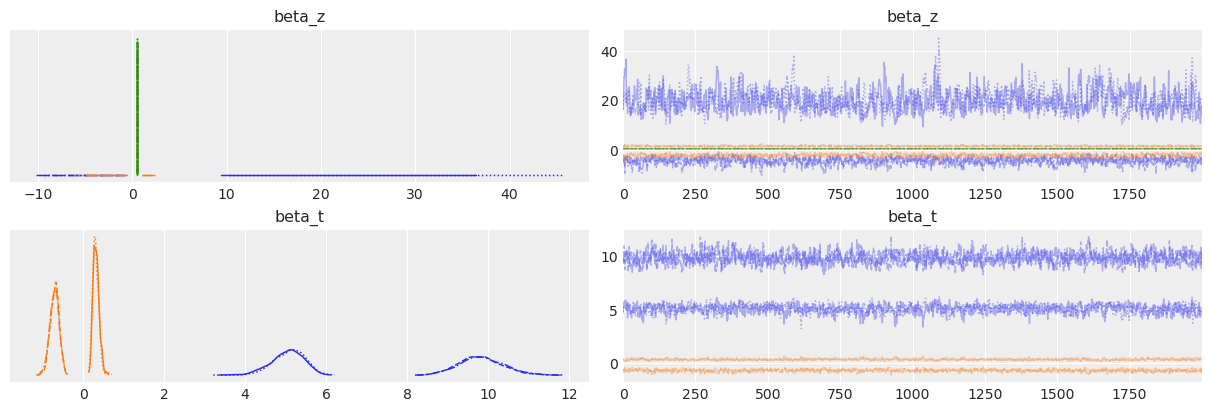

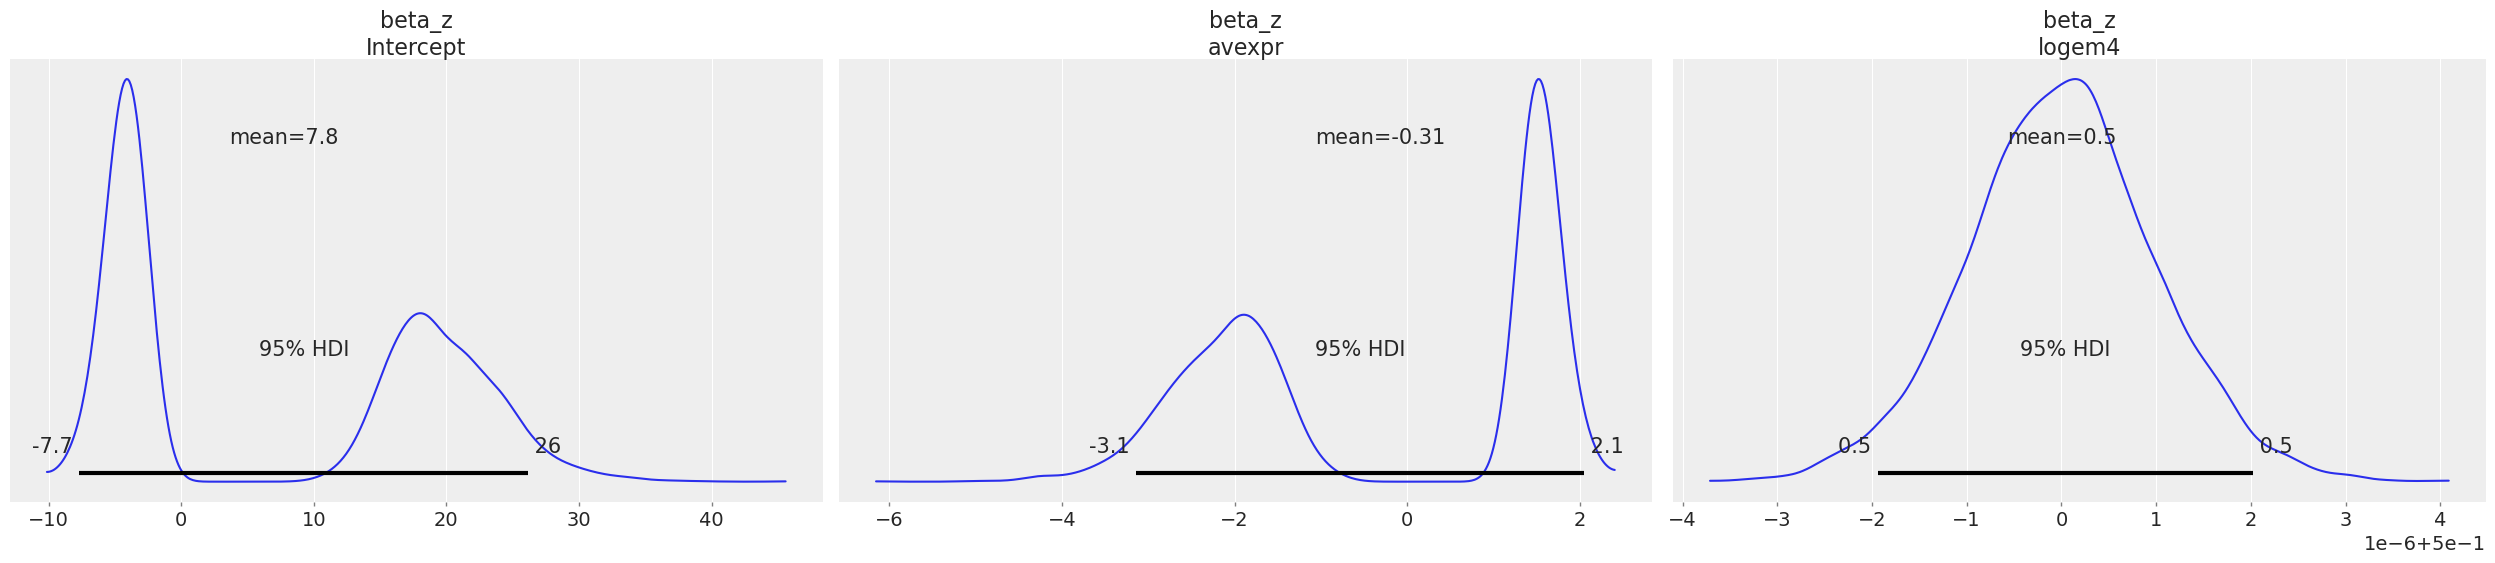

In [6]:
idata2 = az.from_netcdf("ajr_iv_delta_posterior1.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)


Computing correlations for 8000 posterior samples...

=== BAYESIAN EXCLUSION RESTRICTION TEST ===
Posterior median correlation: -0.531
95% HDI: [-0.861, 0.478]
HDI contains zero: True
✓ PASS: Cannot reject exclusion restriction (HDI contains 0)


C:\Users\B375471\AppData\Local\Temp\ipykernel_21904\3797748897.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


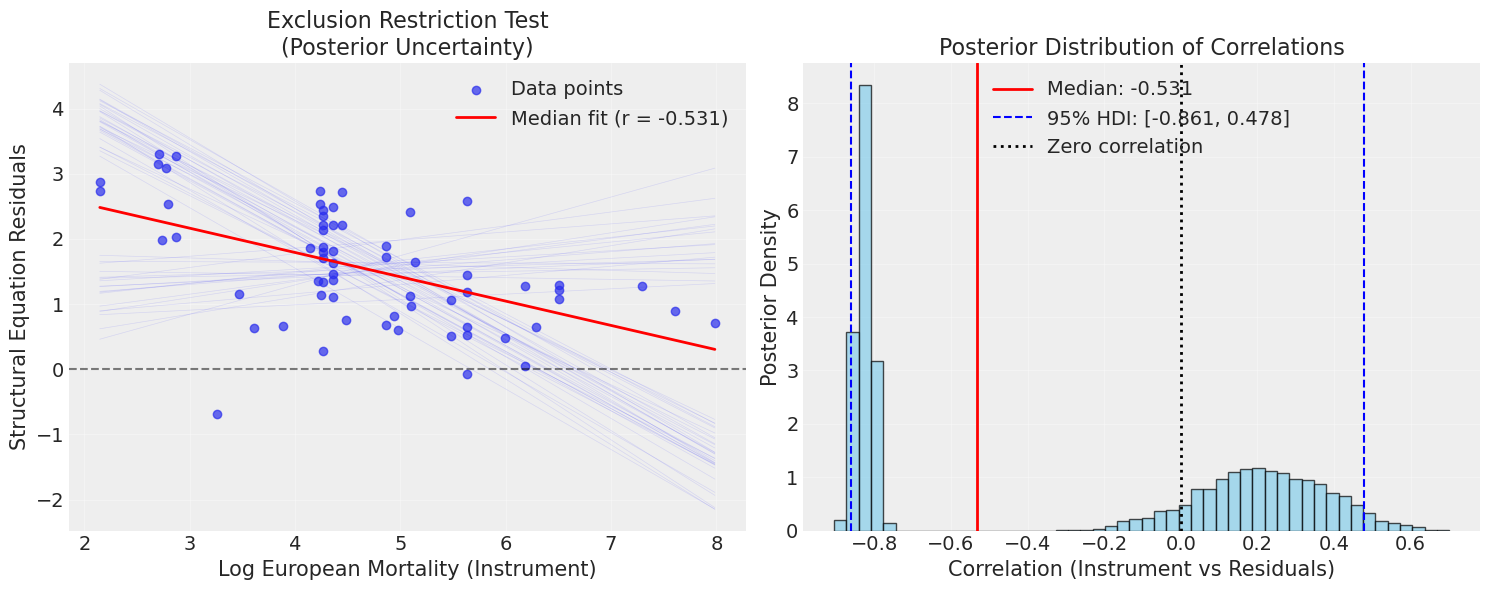


Interpretation:
⚠ WEAK SUPPORT: High correlation but HDI still contains 0

Diagnostic Information:
Standard deviation of posterior correlations: 0.5335
Range of correlations: [-0.905, 0.701]


In [7]:
# Check if residuals from both equations are uncorrelated with instrument
# This tests the exclusion restriction using BAYESIAN POSTERIOR SAMPLES
import xarray as xr

# Use the same filtered data and predictions from previous cells
first_stage_preds = idata2.posterior['mu'].isel(mu_dim_1=0)  # First stage (avexpr) predictions
structural_preds = idata2.posterior['mu'].isel(mu_dim_1=1)  # Structural (logpgp95) predictions

# Calculate residuals for each posterior sample
observed_logpgp95 = df_ajr['logpgp95'].values
observed_logem4 = df_ajr['logem4'].values

# Calculate correlations for each posterior sample
n_chains, n_draws, n_obs = structural_preds.shape
correlations_posterior = []

print(f"Computing correlations for {n_chains * n_draws} posterior samples...")

for chain in range(n_chains):
    for draw in range(n_draws):
        # Get residuals for this posterior sample
        pred_logpgp95 = structural_preds[chain, draw, :].values
        residuals = observed_logpgp95 - pred_logpgp95
        
        # Calculate correlation between instrument and residuals
        corr = np.corrcoef(observed_logem4, residuals)[0, 1]
        correlations_posterior.append(corr)

correlations_posterior = np.array(correlations_posterior)

# Calculate HDI from posterior samples
hdi_lower = np.percentile(correlations_posterior, 2.5)
hdi_upper = np.percentile(correlations_posterior, 97.5)
corr_median = np.median(correlations_posterior)

print(f"\n=== BAYESIAN EXCLUSION RESTRICTION TEST ===")
print(f"Posterior median correlation: {corr_median:.3f}")
print(f"95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]")

# Test if HDI contains zero
contains_zero = hdi_lower <= 0 <= hdi_upper
print(f"HDI contains zero: {contains_zero}")

if contains_zero:
    print("✓ PASS: Cannot reject exclusion restriction (HDI contains 0)")
else:
    print("✗ FAIL: Evidence against exclusion restriction (HDI excludes 0)")

# Visualization using posterior samples
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Scatter with median residuals
median_residuals = observed_logpgp95 - structural_preds.mean(['chain', 'draw']).values
ax1.scatter(observed_logem4, median_residuals, alpha=0.7, label='Data points')

# Show uncertainty with individual posterior samples (subsample for clarity)
n_sample_lines = 50
sample_indices = np.random.choice(len(correlations_posterior), n_sample_lines, replace=False)

for i, idx in enumerate(sample_indices):
    chain_idx = idx // n_draws
    draw_idx = idx % n_draws
    
    pred_sample = structural_preds[chain_idx, draw_idx, :].values
    residuals_sample = observed_logpgp95 - pred_sample
    
    # Fit line for this sample
    slope, intercept = np.polyfit(observed_logem4, residuals_sample, 1)
    line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
    line_y = slope * line_x + intercept
    
    ax1.plot(line_x, line_y, 'blue', alpha=0.1, linewidth=0.5)

# Overall median line
median_slope, median_intercept = np.polyfit(observed_logem4, median_residuals, 1)
line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
median_line_y = median_slope * line_x + median_intercept
ax1.plot(line_x, median_line_y, 'red', linewidth=2, label=f'Median fit (r = {corr_median:.3f})')

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Log European Mortality (Instrument)')
ax1.set_ylabel('Structural Equation Residuals')
ax1.set_title('Exclusion Restriction Test\n(Posterior Uncertainty)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Posterior distribution of correlations
ax2.hist(correlations_posterior, bins=50, alpha=0.7, density=True, color='skyblue', edgecolor='black')
ax2.axvline(corr_median, color='red', linestyle='-', linewidth=2, label=f'Median: {corr_median:.3f}')
ax2.axvline(hdi_lower, color='blue', linestyle='--', label=f'95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]')
ax2.axvline(hdi_upper, color='blue', linestyle='--')
ax2.axvline(0, color='black', linestyle=':', linewidth=2, label='Zero correlation')
ax2.set_xlabel('Correlation (Instrument vs Residuals)')
ax2.set_ylabel('Posterior Density')
ax2.set_title('Posterior Distribution of Correlations')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary assessment
print(f"\nInterpretation:")
if abs(corr_median) < 0.1 and contains_zero:
    print("✓ STRONG SUPPORT: Low correlation and HDI contains 0")
elif abs(corr_median) < 0.2 and contains_zero:
    print("✓ MODERATE SUPPORT: Modest correlation but HDI contains 0")
elif contains_zero:
    print("⚠ WEAK SUPPORT: High correlation but HDI still contains 0")
else:
    print("✗ NO SUPPORT: Correlation significantly different from 0")

# Additional diagnostic: Show how much uncertainty comes from posterior vs sampling
print(f"\nDiagnostic Information:")
print(f"Standard deviation of posterior correlations: {np.std(correlations_posterior):.4f}")
print(f"Range of correlations: [{np.min(correlations_posterior):.3f}, {np.max(correlations_posterior):.3f}]")

In [ ]:
# Create proper posterior predictive data and use az.plot_ppc
import xarray as xr

# Extract structural equation predictions (logpgp95)
structural_preds = idata.posterior['mu'].isel(mu_dim_1=1)  # logpgp95 predictions

# Get observed logpgp95 values
df_ajr = pd.read_stata(r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")
df_ajr = df_ajr.dropna(subset=['logem4', 'logpgp95', 'avexpr'])  # Same filtering as in ajr module
observed_logpgp95 = df_ajr['logpgp95'].values

# Add the logpgp95 predictions to posterior_predictive group
idata.posterior_predictive = idata.posterior_predictive.assign(
    logpgp95=structural_preds.rename(mu_dim_0='logpgp95_dim_0')
)

# Add the observed logpgp95 data to observed_data group
observed_da = xr.DataArray(
    observed_logpgp95, 
    dims=['logpgp95_dim_0'],
    coords={'logpgp95_dim_0': range(len(observed_logpgp95))}
)
idata.observed_data = idata.observed_data.assign(logpgp95=observed_da)

# Remove likelihood from both groups to avoid confusion
idata.posterior_predictive = idata.posterior_predictive.drop_vars('likelihood')
idata.observed_data = idata.observed_data.drop_vars('likelihood')

# Now use az.plot_ppc with proper data - specify only logpgp95
az.plot_ppc(
    idata,
    data_pairs={"logpgp95": "logpgp95"},
    var_names=["logpgp95"],  # Only plot logpgp95, not likelihood
    figsize=(10, 6),
)

print(f"Observed logpgp95 mean: {observed_logpgp95.mean():.3f}")
print(f"Predicted logpgp95 mean: {structural_preds.mean().values:.3f}")
print(f"Observed logpgp95 std: {observed_logpgp95.std():.3f}")
print(f"Predicted logpgp95 std: {structural_preds.std().values:.3f}")

In [ ]:

iv2 = ajr.run(baseline_only=True, draws=2000, tune=1000, chains=4, cores=4, covariates=['asia', 'africa', 'other_cont', 'lat_abst'], data_path=r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta", netcdf_path="ajr_iv_posterior2.nc")

In [ ]:
idata2 = az.from_netcdf("ajr_iv_posterior2.nc")
az.plot_trace(idata2, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata2, var_names=["beta_z"], hdi_prob=0.95)



In [ ]:
# Same trace plot as above but with variable labels added
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
idata2 = az.from_netcdf("ajr_iv_posterior2.nc")

# Get the coordinate labels
beta_z_coords = list(idata2.posterior.coords['covariates'].values)
beta_t_coords = list(idata2.posterior.coords['instruments'].values)

print("β_z components:", beta_z_coords)
print("β_t components:", beta_t_coords)

# Create the trace plot with enhanced labeling
axes = az.plot_trace(idata2, var_names=["beta_z", "beta_t"], figsize=(16, 12))

# Get the figure and add title
fig = axes.flat[0].figure
fig.suptitle("Trace Plots with Variable Labels", fontsize=14, y=0.95)

# Get default color cycle for mapping
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add legends to each subplot with color mapping
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        if j == 0:  # Left column (trace plots)
            if i == 0:  # beta_z
                # Create legend entries for beta_z components
                legend_elements = [plt.Line2D([0], [0], color=colors[k % len(colors)], 
                                            lw=2, label=f'{coord}') 
                                 for k, coord in enumerate(beta_z_coords)]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
                ax.set_title('β_z (Covariates) - Trace', fontsize=12)
            elif i == 1:  # beta_t  
                # Create legend entries for beta_t components
                legend_elements = [plt.Line2D([0], [0], color=colors[k % len(colors)], 
                                            lw=2, label=f'{coord}') 
                                 for k, coord in enumerate(beta_t_coords)]
                ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
                ax.set_title('β_t (Instruments) - Trace', fontsize=12)
        else:  # Right column (density plots)
            if i == 0:
                ax.set_title('β_z (Covariates) - Density', fontsize=12)
            elif i == 1:
                ax.set_title('β_t (Instruments) - Density', fontsize=12)

plt.tight_layout()
plt.show()